In [1]:
# Importlari adim adim ve sureleriyle yukle
import time
_cell_start = time.time()

_t = time.time()
import torch
print(f"[OK] torch ({time.time() - _t:.2f}s)")

_t = time.time()
import torch.nn as nn
print(f"[OK] torch.nn ({time.time() - _t:.2f}s)")

_t = time.time()
import torch.optim as optim
print(f"[OK] torch.optim ({time.time() - _t:.2f}s)")

_t = time.time()
from torch.utils.data import DataLoader, WeightedRandomSampler
print(f"[OK] torch.utils.data ({time.time() - _t:.2f}s)")

_t = time.time()
from torchvision import datasets, transforms
print(f"[OK] torchvision ({time.time() - _t:.2f}s)")

_t = time.time()
import timm
print(f"[OK] timm ({time.time() - _t:.2f}s)")

_t = time.time()
from transformers import CvtForImageClassification
print(f"[OK] transformers.CvtForImageClassification ({time.time() - _t:.2f}s)")

_t = time.time()
import os
print(f"[OK] os ({time.time() - _t:.2f}s)")

_t = time.time()
import matplotlib.pyplot as plt
print(f"[OK] matplotlib.pyplot ({time.time() - _t:.2f}s)")

_t = time.time()
from sklearn.metrics import classification_report, confusion_matrix, f1_score, recall_score
print(f"[OK] sklearn.metrics ({time.time() - _t:.2f}s)")

_t = time.time()
import seaborn as sns
print(f"[OK] seaborn ({time.time() - _t:.2f}s)")

_t = time.time()
import pandas as pd
print(f"[OK] pandas ({time.time() - _t:.2f}s)")

_t = time.time()
import numpy as np
print(f"[OK] numpy ({time.time() - _t:.2f}s)")

import warnings
warnings.filterwarnings("ignore")

# --- GLOBAL AYARLAR VE TEKRARLANABILIRLIK ---
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f"1. hucre importlari tamamlandi. Toplam sure: {time.time() - _cell_start:.2f}s")

[OK] torch (4.06s)
[OK] torch.nn (0.00s)
[OK] torch.optim (0.00s)
[OK] torch.utils.data (0.00s)
[OK] torchvision (1.44s)


c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\.venv313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] timm (0.69s)
[OK] transformers.CvtForImageClassification (3.68s)
[OK] os (0.00s)
[OK] matplotlib.pyplot (0.32s)
[OK] sklearn.metrics (0.00s)
[OK] seaborn (0.06s)
[OK] pandas (0.00s)
[OK] numpy (0.00s)
1. hucre importlari tamamlandi. Toplam sure: 10.25s


In [10]:
# --- KONFIGURASYON (CvT - Convolutional Vision Transformer) ---
# CvT-13 Modeli (timm kodu: cvt_13)
MODEL_NAME = 'cvt_13'

# Deney Adi
EXPERIMENT_NAME = "CvT13_Img256_ValLoss_Run1"

# Hiperparametreler (tek notebook uzerinden yeni CvT denemesi)
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 8e-5
NUM_CLASSES = 8
DROPOUT_RATE = 0.1
WEIGHT_DECAY = 5e-4
LABEL_SMOOTHING = 0.01
WARMUP_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 12
EARLY_STOPPING_METRIC = 'val_loss'
EARLY_STOPPING_MIN_DELTA = 1e-4
IMAGE_SIZE = 256

# Dengesiz veri stratejisi (augsuz, hedefli sinif agirligi)
USE_CLASS_WEIGHTED_LOSS = True
CLASS_WEIGHT_MODE = 'manual_boost'  # manual_boost | auto_inverse_freq
TARGET_CLASS_WEIGHT_BOOST = {
    'esophagitis': 1.35,
    'normal-z-line': 1.25
}
IMBALANCE_RATIO_THRESHOLD = 1.5
FORCE_WEIGHTED_SAMPLER = False

# Notebook + Windows icin daha stabil DataLoader ayari
NUM_WORKERS = 0 if os.name == 'nt' else 4

# Proje kok yolunu calisma dizininden bagimsiz bul
cwd = os.getcwd()
if os.path.isdir(os.path.join(cwd, "data", "prepared-data")):
    PROJECT_ROOT = cwd
elif os.path.isdir(os.path.join(cwd, "..", "data", "prepared-data")):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    PROJECT_ROOT = cwd

# --- DOSYA YOLLARI ---
DATA_DIR = os.path.join(PROJECT_ROOT, "data", "prepared-data")

# Calistirma etiketleri (kisa tutularak Windows path sorunu azaltildi)
dropout_tag = f"d{int(round(DROPOUT_RATE * 100)):02d}"
ls_tag = f"ls{int(round(LABEL_SMOOTHING * 100)):02d}"
wd_tag = f"wd{str(WEIGHT_DECAY).replace('.', 'p').replace('-', 'm')}"
lr_tag = f"lr{LEARNING_RATE:g}".replace('.', 'p')
img_tag = f"i{IMAGE_SIZE}"
sampler_tag = "s1" if FORCE_WEIGHTED_SAMPLER else "s0"
es_tag = "esa" if EARLY_STOPPING_METRIC == 'val_acc' else "esl"
wloss_tag = "wl1" if USE_CLASS_WEIGHTED_LOSS else "wl0"
RUN_TAG = f"{dropout_tag}_{ls_tag}_{wd_tag}_b{BATCH_SIZE}_e{EPOCHS}_{lr_tag}_{img_tag}_{sampler_tag}_{es_tag}_{wloss_tag}"
RUN_NAME = f"{EXPERIMENT_NAME}_{RUN_TAG}"

# Sonuclarin kaydedilecegi yer (uzun yol hatasina karsi fallback)
primary_output_dir = os.path.join(PROJECT_ROOT, "models", "pytorch", RUN_NAME)
fallback_output_dir = os.path.join(PROJECT_ROOT, "outputs", MODEL_NAME, "runs", RUN_TAG)
try:
    os.makedirs(primary_output_dir, exist_ok=True)
    OUTPUT_DIR = primary_output_dir
except OSError:
    os.makedirs(fallback_output_dir, exist_ok=True)
    OUTPUT_DIR = fallback_output_dir
    print("Uyari: Uzun yol nedeniyle fallback OUTPUT_DIR kullaniliyor.")

# En iyi model dosya yolu
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, f"best_{MODEL_NAME}_{RUN_TAG}.pth")

# Cihaz Kontrolu
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"CWD: {cwd}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Cihaz: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Model: {MODEL_NAME}")
print(f"Run Tag: {RUN_TAG}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"Kayit Yeri: {OUTPUT_DIR}")
print(f"Best Model Yolu: {BEST_MODEL_PATH}")
print(f"NUM_WORKERS: {NUM_WORKERS}")

CWD: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\CVT
PROJECT_ROOT: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison
Cihaz: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
Model: cvt_13
Run Tag: d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1
DATA_DIR: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\data\prepared-data
Kayit Yeri: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1
Best Model Yolu: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1\best_cvt_13_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.pth
NUM_WORKERS: 0


In [3]:
# ImageNet Normalize Degerleri
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# Cikti klasoru garanti
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Veri Donusumleri (ana veri uzerinden: augmentation yok)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean, std)
    ])
}

# Datasetleri Olustur
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

# Sinif dengesizligi analizi
train_targets = np.array(image_datasets['train'].targets)
class_sample_counts = np.bincount(train_targets, minlength=NUM_CLASSES)
imbalance_ratio = class_sample_counts.max() / max(1, class_sample_counts.min())
AUTO_USE_WEIGHTED_SAMPLER = imbalance_ratio >= IMBALANCE_RATIO_THRESHOLD
USE_WEIGHTED_SAMPLER = FORCE_WEIGHTED_SAMPLER or AUTO_USE_WEIGHTED_SAMPLER

class_weight_values = class_sample_counts.sum() / (NUM_CLASSES * np.clip(class_sample_counts, 1, None))
CLASS_WEIGHTS_TENSOR = torch.tensor(class_weight_values, dtype=torch.float32)

# Hedefli manuel sinif agirliklari (karisan siniflara ekstra ceza)
class_names = image_datasets['train'].classes
manual_class_weights = np.ones(NUM_CLASSES, dtype=np.float32)
for class_name, boost in TARGET_CLASS_WEIGHT_BOOST.items():
    if class_name in class_names:
        manual_class_weights[class_names.index(class_name)] = float(boost)
MANUAL_CLASS_WEIGHTS_TENSOR = torch.tensor(manual_class_weights, dtype=torch.float32)

train_sampler = None
if USE_WEIGHTED_SAMPLER:
    sample_weights = class_weight_values[train_targets]
    train_sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )

# DataLoaderlari Olustur
dataloaders = {
    'train': DataLoader(
        image_datasets['train'],
        batch_size=BATCH_SIZE,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        num_workers=NUM_WORKERS,
        pin_memory=True
    ),
    'val': DataLoader(image_datasets['val'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True),
    'test': DataLoader(image_datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
}

dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val', 'test']}

# Basit veri sizintisi kontrolu: train-val/test ayni dosya adlari
train_files = set(os.path.basename(p).lower() for p, _ in image_datasets['train'].samples)
val_files = set(os.path.basename(p).lower() for p, _ in image_datasets['val'].samples)
test_files = set(os.path.basename(p).lower() for p, _ in image_datasets['test'].samples)
overlap_train_val = train_files.intersection(val_files)
overlap_train_test = train_files.intersection(test_files)

leak_report_path = os.path.join(OUTPUT_DIR, f"leakage_check_{RUN_TAG}.txt")
with open(leak_report_path, "w", encoding="utf-8") as f:
    f.write(f"Train-Val same filename count: {len(overlap_train_val)}\n")
    f.write(f"Train-Test same filename count: {len(overlap_train_test)}\n")
    if overlap_train_val:
        f.write("Sample Train-Val overlaps:\n")
        f.write("\n".join(list(sorted(overlap_train_val))[:20]))
        f.write("\n")
    if overlap_train_test:
        f.write("Sample Train-Test overlaps:\n")
        f.write("\n".join(list(sorted(overlap_train_test))[:20]))
        f.write("\n")

print(f"Siniflar: {class_names}")
print(f"Egitim Verisi: {dataset_sizes['train']}")
print(f"Validasyon Verisi: {dataset_sizes['val']}")
print(f"Test Verisi: {dataset_sizes['test']}")
print(f"Sinif sayimlari (train): {class_sample_counts.tolist()}")
print(f"Imbalance ratio (max/min): {imbalance_ratio:.2f}")
print(f"Weighted sampler otomatik onerisi: {AUTO_USE_WEIGHTED_SAMPLER}")
print(f"Weighted sampler zorla acik: {FORCE_WEIGHTED_SAMPLER}")
print(f"Weighted sampler aktif: {USE_WEIGHTED_SAMPLER}")
print(f"Class-weighted loss aktif: {USE_CLASS_WEIGHTED_LOSS} ({CLASS_WEIGHT_MODE})")
print(f"Manual class weights: {manual_class_weights.tolist()}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print(f"Leakage raporu: {leak_report_path}")

Siniflar: ['dyed-lifted-polyps', 'dyed-resection-margins', 'esophagitis', 'normal-cecum', 'normal-pylorus', 'normal-z-line', 'polyps', 'ulcerative-colitis']
Egitim Verisi: 5592
Validasyon Verisi: 1200
Test Verisi: 1208
Sinif sayimlari (train): [699, 699, 699, 699, 699, 699, 699, 699]
Imbalance ratio (max/min): 1.00
Weighted sampler otomatik onerisi: False
Weighted sampler zorla acik: False
Weighted sampler aktif: False
Class-weighted loss aktif: True (manual_boost)
Manual class weights: [1.0, 1.0, 1.350000023841858, 1.0, 1.0, 1.25, 1.0, 1.0]
NUM_WORKERS: 0
Leakage raporu: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1\leakage_check_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.txt


In [4]:
def get_logits(model_output):
    if hasattr(model_output, 'logits'):
        return model_output.logits
    return model_output

def create_model():
    print(f"Model indiriliyor: {MODEL_NAME}...")

    available_models = set(timm.list_models())
    candidate_models = [
        MODEL_NAME,
        "cvt_13.in1k",
        "cvt_13.fb_in1k",
        "cvt_13.fb_in22k_ft_in1k",
        "cvt_13.ms_in22k_ft_in1k",
        "cvt_13_384.in1k"
    ]

    resolved_model_name = next((m for m in candidate_models if m in available_models), None)

    if resolved_model_name is not None:
        print(f"Kullanilan timm model adi: {resolved_model_name}")
        model = timm.create_model(
            resolved_model_name,
            pretrained=True,
            num_classes=NUM_CLASSES,
            drop_rate=DROPOUT_RATE
        )
        return model

    print("timm uzerinde CvT bulunamadi, transformers fallback kullaniliyor: microsoft/cvt-13")
    model = CvtForImageClassification.from_pretrained(
        "microsoft/cvt-13",
        num_labels=NUM_CLASSES,
        ignore_mismatched_sizes=True
    )
    return model

model = create_model()
model = model.to(DEVICE)

# Kayip Fonksiyonu ve Optimizer
loss_weight = None
if USE_CLASS_WEIGHTED_LOSS:
    if CLASS_WEIGHT_MODE == 'auto_inverse_freq':
        loss_weight = CLASS_WEIGHTS_TENSOR.to(DEVICE)
    else:
        loss_weight = MANUAL_CLASS_WEIGHTS_TENSOR.to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING, weight=loss_weight)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Warmup + CosineAnnealing benzeri plan (LambdaLR)
def lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return float(epoch + 1) / float(max(1, WARMUP_EPOCHS))
    progress = (epoch - WARMUP_EPOCHS) / float(max(1, EPOCHS - WARMUP_EPOCHS))
    progress = min(max(progress, 0.0), 1.0)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

print("CvT model GPU'ya yuklendi ve egitime hazir.")
print(f"AdamW + weight_decay={WEIGHT_DECAY}, label_smoothing={LABEL_SMOOTHING}")
print(f"Loss weighting aktif: {USE_CLASS_WEIGHTED_LOSS} | mode: {CLASS_WEIGHT_MODE}")

Model indiriliyor: cvt_13...
timm uzerinde CvT bulunamadi, transformers fallback kullaniliyor: microsoft/cvt-13


Loading weights: 100%|██████████| 459/459 [00:00<00:00, 11679.26it/s]
CvtForImageClassification LOAD REPORT from: microsoft/cvt-13
Key               | Status   |                                                                                          
------------------+----------+------------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000, 384]) vs model:torch.Size([8, 384])
classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([1000]) vs model:torch.Size([8])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


CvT model GPU'ya yuklendi ve egitime hazir.
AdamW + weight_decay=0.0005, label_smoothing=0.01
Loss weighting aktif: True | mode: manual_boost


In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs):
    required_globals = [
        "dataloaders", "dataset_sizes", "OUTPUT_DIR", "DEVICE", "BEST_MODEL_PATH", "EARLY_STOPPING_PATIENCE",
        "get_logits", "EARLY_STOPPING_METRIC", "EARLY_STOPPING_MIN_DELTA"
    ]
    missing = [name for name in required_globals if name not in globals()]
    if missing:
        raise RuntimeError(
            f"Eksik degisken(ler): {missing}. Lutfen once veri ve konfigurasyon hucrelerini calistirin."
        )

    os.makedirs(OUTPUT_DIR, exist_ok=True)
    os.makedirs(os.path.dirname(BEST_MODEL_PATH), exist_ok=True)

    since = time.time()
    best_acc = 0.0
    best_val_loss = float('inf')
    if EARLY_STOPPING_METRIC == 'val_acc':
        best_monitor_value = -float('inf')
    else:
        best_monitor_value = float('inf')

    epochs_without_improvement = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        epoch_metrics = {}

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    model_output = model(inputs)
                    outputs = get_logits(model_output)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            epoch_acc_value = epoch_acc.item()

            epoch_metrics[f'{phase}_loss'] = epoch_loss
            epoch_metrics[f'{phase}_acc'] = epoch_acc_value

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc_value:.4f}')
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc_value)

            if phase == 'val':
                if epoch_acc_value > best_acc:
                    best_acc = epoch_acc_value
                if epoch_loss < best_val_loss:
                    best_val_loss = epoch_loss

        current_monitor_value = epoch_metrics[EARLY_STOPPING_METRIC]
        if EARLY_STOPPING_METRIC == 'val_acc':
            improved = current_monitor_value > (best_monitor_value + EARLY_STOPPING_MIN_DELTA)
        else:
            improved = current_monitor_value < (best_monitor_value - EARLY_STOPPING_MIN_DELTA)

        if improved:
            best_monitor_value = current_monitor_value
            epochs_without_improvement = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(
                f"En Iyi Model ({EARLY_STOPPING_METRIC}: {current_monitor_value:.4f}) -> {BEST_MODEL_PATH}"
            )
        else:
            epochs_without_improvement += 1
            print(
                f"{EARLY_STOPPING_METRIC} iyilesmedi: {epochs_without_improvement}/{EARLY_STOPPING_PATIENCE}"
            )

        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        history['lr'].append(current_lr)
        print(f"Guncel LR: {current_lr:.8f}")

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print("Erken durdurma tetiklendi.")
            break

    time_elapsed = time.time() - since
    print(f'\nEgitim Tamamlandi: {time_elapsed // 60:.0f}dk {time_elapsed % 60:.0f}sn')
    print(f'En Iyi Validasyon Dogrulugu: {best_acc:.4f}')
    print(f'En Dusuk Validasyon Kaybi: {best_val_loss:.4f}')

    model.load_state_dict(torch.load(BEST_MODEL_PATH))
    return model, history

In [6]:
# --- BASLAT ---
required_vars = ["model", "criterion", "optimizer", "scheduler", "train_model"]
missing = [name for name in required_vars if name not in globals()]
if missing:
    raise RuntimeError(
        f"Eksik degisken(ler): {missing}. Lutfen once model/egitim hazirlik hucrelerini calistirin."
    )

num_epochs = int(globals().get("EPOCHS", 50))
model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=num_epochs)

Epoch 1/50
----------
train Loss: 1.2806 Acc: 0.5815
val Loss: 0.5763 Acc: 0.8250
En Iyi Model (val_loss: 0.5763) -> c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1\best_cvt_13_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.pth
Guncel LR: 0.00005333
Epoch 2/50
----------
train Loss: 0.8014 Acc: 0.7078
val Loss: 0.3488 Acc: 0.8867
En Iyi Model (val_loss: 0.3488) -> c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1\best_cvt_13_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.pth
Guncel LR: 0.00008000
Epoch 3/50
----------
train Loss: 0.6967 Acc: 0.7405
val Loss: 0.2783 Acc: 0.9192
En Iyi Model (val_loss: 0.2783) -> c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\models\pytorch\CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1\best_cvt

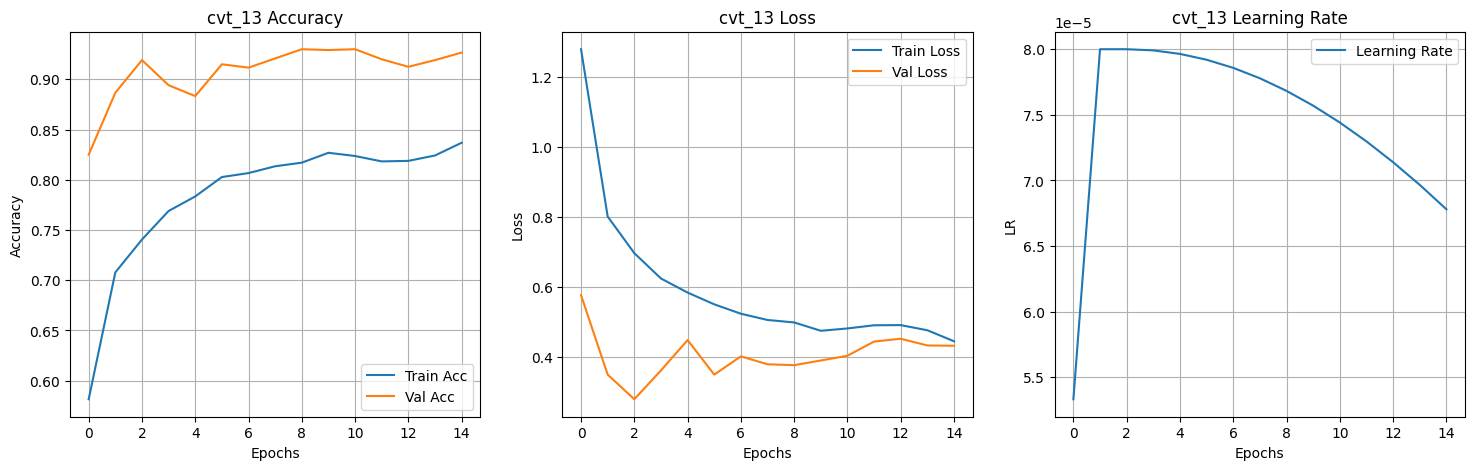

Grafikler kaydedildi: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\outputs\cvt_13\plots\training_graph_cvt_13_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.png


In [7]:
plt.figure(figsize=(18, 5))

# Dogruluk Grafigi
plt.subplot(1, 3, 1)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title(f'{MODEL_NAME} Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Kayip Grafigi
plt.subplot(1, 3, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title(f'{MODEL_NAME} Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# LR Grafigi
plt.subplot(1, 3, 3)
if 'lr' in history and len(history['lr']) > 0:
    plt.plot(history['lr'], label='Learning Rate')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'LR history yok', ha='center', va='center')
plt.title(f'{MODEL_NAME} Learning Rate')
plt.xlabel('Epochs')
plt.ylabel('LR')
plt.grid(True)

# Kaydet ve Goster
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'training_graph_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Grafikler kaydedildi: {plot_path}")


TEST SETI DEGERLENDIRMESI

Siniflandirma Raporu:
                        precision    recall  f1-score   support

    dyed-lifted-polyps     0.9177    0.9603    0.9385       151
dyed-resection-margins     0.9653    0.9205    0.9424       151
           esophagitis     0.8170    0.8278    0.8224       151
          normal-cecum     0.9728    0.9470    0.9597       151
        normal-pylorus     0.9740    0.9934    0.9836       151
         normal-z-line     0.8267    0.8212    0.8239       151
                polyps     0.9241    0.9669    0.9450       151
    ulcerative-colitis     0.9792    0.9338    0.9559       151

              accuracy                         0.9214      1208
             macro avg     0.9221    0.9214    0.9214      1208
          weighted avg     0.9221    0.9214    0.9214      1208

Macro F1: 0.9214
Class recall degerleri:
  dyed-lifted-polyps: 0.9603
  dyed-resection-margins: 0.9205
  esophagitis: 0.8278
  normal-cecum: 0.9470
  normal-pylorus: 0.9934
  norm

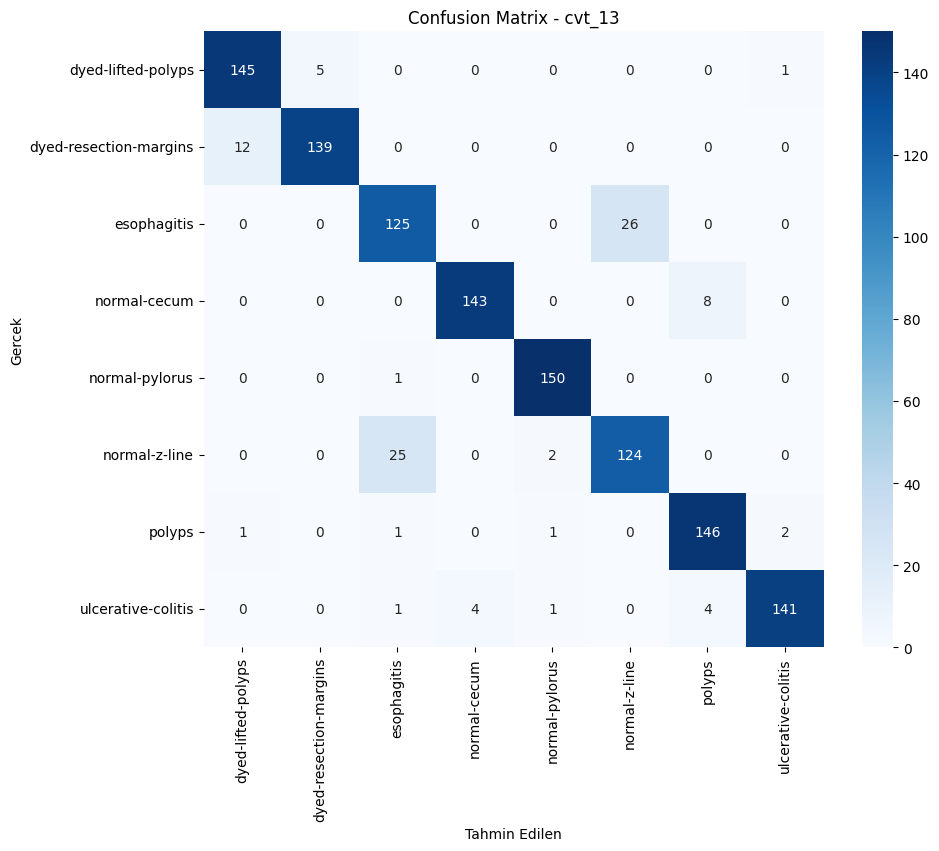

Confusion matrix kaydedildi: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\outputs\cvt_13\plots\confusion_matrix_cvt_13_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1.png
Ablation sonuclari kaydedildi: c:\Users\Gunay\Documents\GitHub\Gastroenterology-CNN-Comparison\outputs\cvt_13\ablation_results_cvt_13.csv
Son kayit:
                                                                   run_name                                           run_tag model_name  batch_size  learning_rate  weight_decay  dropout_rate  label_smoothing  force_weighted_sampler  use_weighted_sampler  use_class_weighted_loss  early_stopping_patience  best_val_acc  best_val_loss  test_macro_f1
CvT13_Img256_ValLoss_Run1_d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1 d10_ls01_wd0p0005_b32_e50_lr8e-05_i256_s0_esl_wl1     cvt_13          32        0.00008        0.0005           0.1             0.01                   False                 False                     True                       12      

In [8]:
print("\nTEST SETI DEGERLENDIRMESI")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(DEVICE)
        model_output = model(inputs)
        outputs = get_logits(model_output)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# 1. Classification Report (F1, Recall, Precision)
print("\nSiniflandirma Raporu:")
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print(report)

macro_f1 = f1_score(y_true, y_pred, average='macro')
class_recalls = recall_score(y_true, y_pred, average=None, labels=list(range(len(class_names))))
print(f"Macro F1: {macro_f1:.4f}")
print("Class recall degerleri:")
for class_name, rec in zip(class_names, class_recalls):
    print(f"  {class_name}: {rec:.4f}")

# Raporu yaz
os.makedirs(OUTPUT_DIR, exist_ok=True)
report_path = os.path.join(OUTPUT_DIR, f'classification_report_{MODEL_NAME}_{RUN_TAG}.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(report)
    f.write(f"\nMacro F1: {macro_f1:.6f}\n")
    f.write("Class Recall:\n")
    for class_name, rec in zip(class_names, class_recalls):
        f.write(f"{class_name}: {rec:.6f}\n")
print(f"Classification report kaydedildi: {report_path}")

# 2. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gercek')
plt.title(f'Confusion Matrix - {MODEL_NAME}')
PLOT_OUTPUT_DIR = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, 'plots')
os.makedirs(PLOT_OUTPUT_DIR, exist_ok=True)
plot_path = os.path.join(PLOT_OUTPUT_DIR, f'confusion_matrix_{MODEL_NAME}_{RUN_TAG}.png')
plt.savefig(plot_path)
plt.show()
print(f"Confusion matrix kaydedildi: {plot_path}")

# 3. Ablation sonuclarini tek CSV dosyasina ekle
latest_metrics = {
    'run_name': RUN_NAME,
    'run_tag': RUN_TAG,
    'model_name': MODEL_NAME,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'dropout_rate': DROPOUT_RATE,
    'label_smoothing': LABEL_SMOOTHING,
    'force_weighted_sampler': FORCE_WEIGHTED_SAMPLER,
    'use_weighted_sampler': USE_WEIGHTED_SAMPLER,
    'use_class_weighted_loss': USE_CLASS_WEIGHTED_LOSS,
    'early_stopping_patience': EARLY_STOPPING_PATIENCE,
    'best_val_acc': float(max(history['val_acc'])) if 'history' in globals() else None,
    'best_val_loss': float(min(history['val_loss'])) if 'history' in globals() else None,
    'test_macro_f1': float(macro_f1)
}

ablation_csv_path = os.path.join(PROJECT_ROOT, 'outputs', MODEL_NAME, f'ablation_results_{MODEL_NAME}.csv')
os.makedirs(os.path.dirname(ablation_csv_path), exist_ok=True)

new_row_df = pd.DataFrame([latest_metrics])
if os.path.exists(ablation_csv_path):
    old_df = pd.read_csv(ablation_csv_path)
    if 'run_tag' in old_df.columns:
        old_df = old_df[old_df['run_tag'] != RUN_TAG]
    result_df = pd.concat([old_df, new_row_df], ignore_index=True)
else:
    result_df = new_row_df

result_df.to_csv(ablation_csv_path, index=False)
print(f"Ablation sonuclari kaydedildi: {ablation_csv_path}")
print("Son kayit:")
print(new_row_df.to_string(index=False))